In [1]:
import pandas as pd
import numpy as np
from IPython.display import Image, HTML

In [77]:
df = pd.read_csv('amazon_specs_combined.csv')

In [ ]:
df[df['category'] != 'Out of Scope']

In [80]:
df['category'].value_counts()

category
Office, Printing & Power        1784
Audio & Media Systems            958
Accessories                      871
Out of Scope                     671
Peripherals & Input              670
PC Components (Core)             571
Cameras, Photography & Video     565
Computers & Gaming               490
Displays & Mounting              429
Networking & Smart Home          321
Mobile Devices                   256
Name: count, dtype: int64

In [78]:
df[df['category'] == 'Cameras, Photography & Video']['subtype'].value_counts()

subtype
excluded             105
lens                 104
security_cam          72
mirrorless_dslr       42
tripod                39
webcam                32
action_cam            26
digital_camera        25
photo_flash           22
instant_camera        19
drone                 17
gimbal_tripod         14
video_conf_system     13
light                 12
monitor                8
cinema_camera          6
dslr_camera            4
disposable_camera      3
camcorder              2
Name: count, dtype: int64

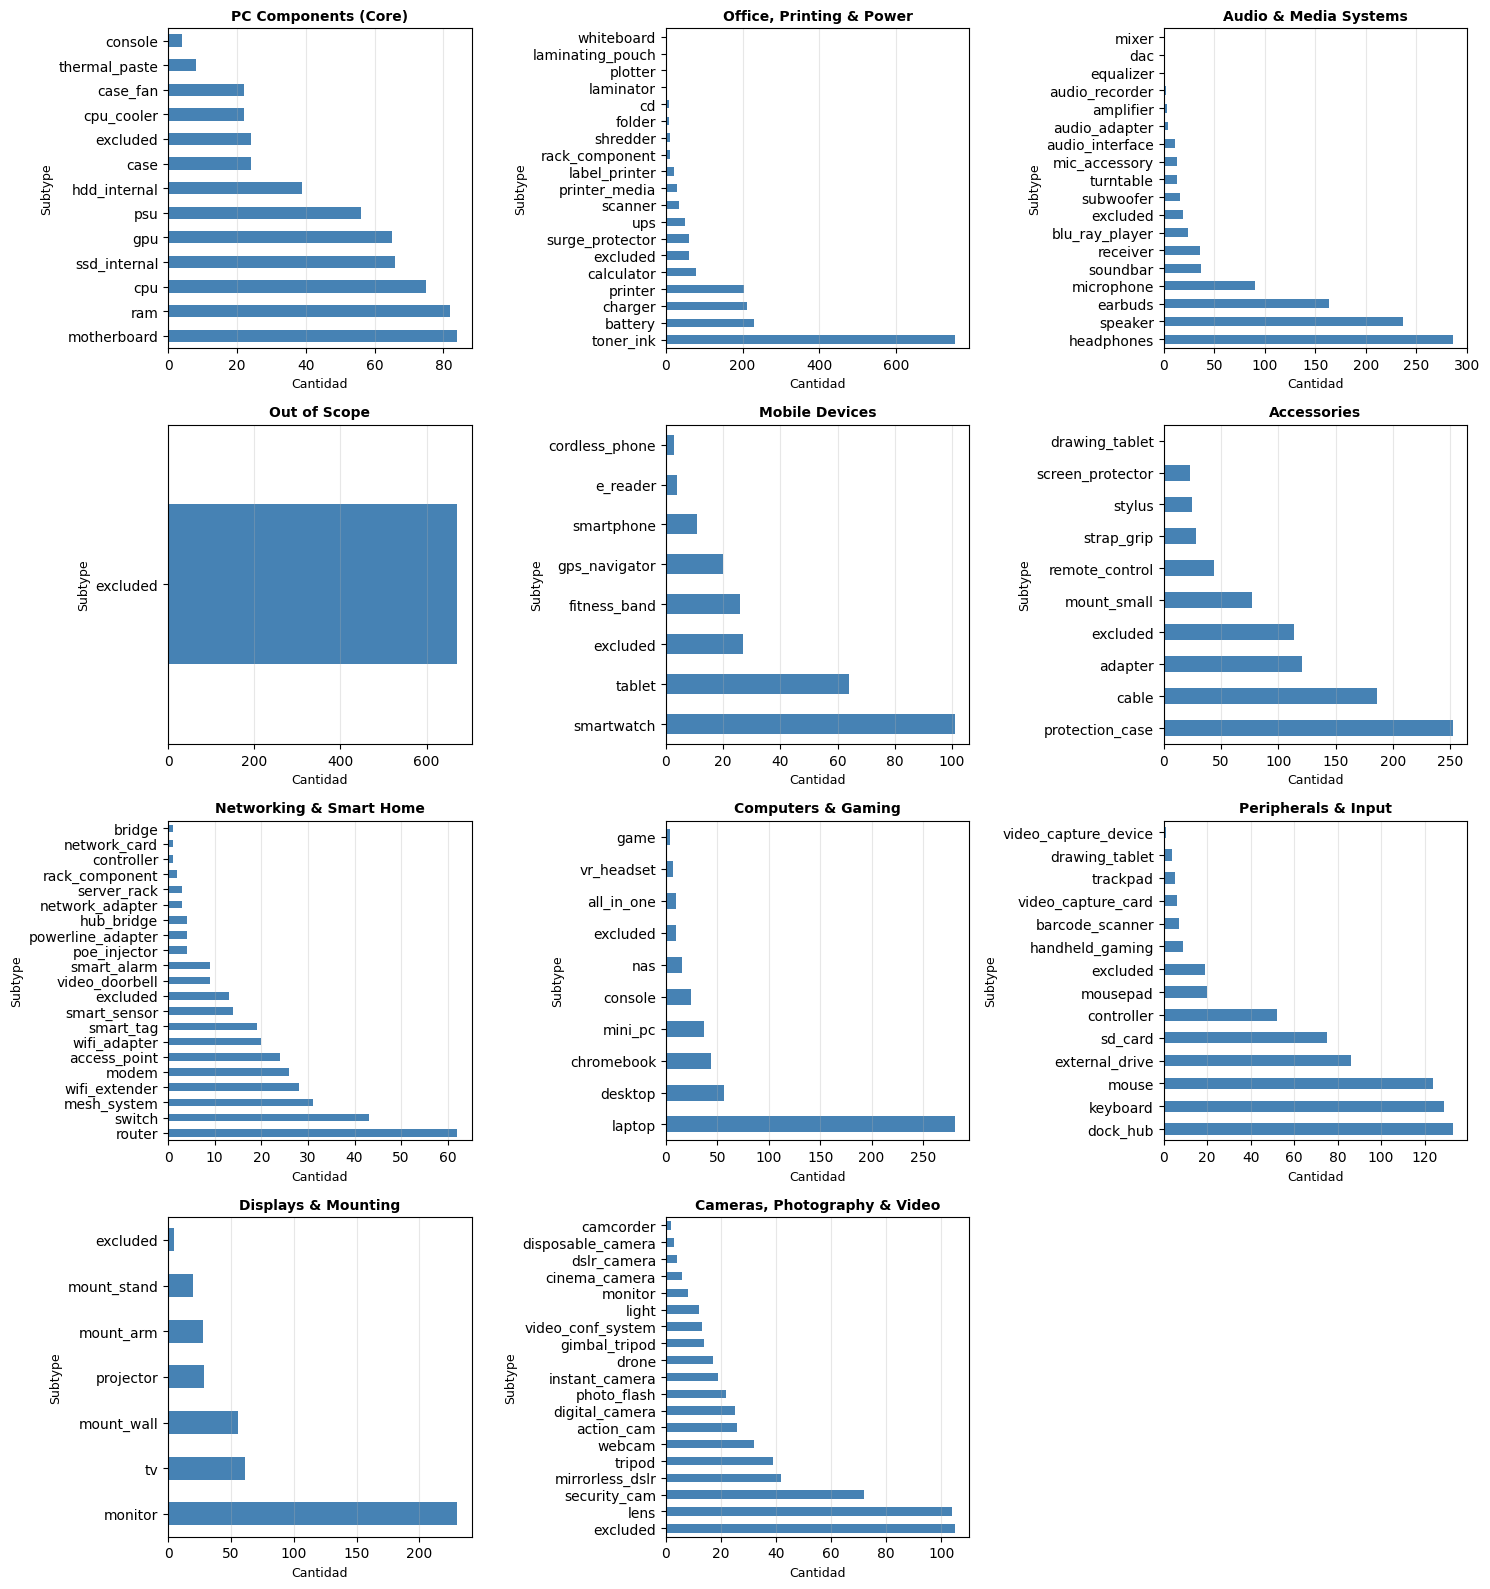

In [79]:
import matplotlib.pyplot as plt

# Obtener todas las categorías únicas
categorias = df['category'].unique()

# Crear un dashboard con subplots en grid de 3 columnas
num_cols = 3
num_rows = (len(categorias) + num_cols - 1) // num_cols  # Redondea hacia arriba

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4*num_rows))
axes = axes.flatten()  # Convierte a array 1D para iterar fácilmente

# Iterar sobre cada categoría y crear una gráfica
for idx, categoria in enumerate(categorias):
    # Calcular los conteos
    subtype_counts = df[df['category'] == categoria]['subtype'].value_counts()

    # --- CORRECCIÓN AQUÍ ---
    # Si no hay datos (la serie está vacía), ocultamos el eje y saltamos al siguiente
    if subtype_counts.empty:
        axes[idx].set_visible(False)
        print(f"⚠️ Aviso: La categoría '{categoria}' no tiene subtipos válidos (posibles NaNs).")
        continue
    # -----------------------

    subtype_counts.plot(kind='barh', ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'{categoria}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Cantidad', fontsize=9)
    axes[idx].set_ylabel('Subtype', fontsize=9)
    axes[idx].grid(axis='x', alpha=0.3)

# Ocultar los subplots sobrantes (si el grid es más grande que las categorías)
for idx in range(len(categorias), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [41]:
total_excluded = ((df['subtype'] == 'excluded') & (df['category'] != 'Out of Scope')).sum()
porcentaje = (total_excluded / len(df)) * 100

print(f"📊 Total de productos 'excluded': {total_excluded}")
print(f"📉 Representan el {porcentaje:.2f}% de tu dataset total.")

📊 Total de productos 'excluded': 397
📉 Representan el 5.23% de tu dataset total.


In [81]:
# 1. Carga tus datos (ajusta los nombres de tus archivos)
df_specs = pd.read_csv('amazon_specs_combined.csv')
df_prices = pd.read_csv('../../Datasets/amazon_final.csv')

# 2. Une ambos datasets (usando el ID o el Título como llave)
df_final = pd.merge(
    df_specs, 
    df_prices, 
    left_on='original_title', 
    right_on='product_title'
)

# 3. Revertir el log1 para ver el precio real
# Si usaste log natural (ln(1+x)):
df_final['price_real'] = np.exp(df_final['log_original_price']) - 1

# Si usaste log base 10 (log10(1+x)):
# df['price_real'] = (10 ** df['log1_price']) - 1

# 4. Filtrar por la categoría Accesorios y ordenar por precio de mayor a menor
expensive_accessories = df_final[(df_final['category'] == 'Out of Scope') & (df_final['subtype'] == 'excluded')].sort_values(by='price_real', ascending=True).iloc[0:700]
# 5. Mostrar el Top 20
print("AUDITORÍA DE ACCESORIOS CAROS:")

# 1. Definimos una función que envuelve la URL en una etiqueta HTML <img>
def render_image(url):
    return f'<img src="{url}" width="80" >'

# 2. Seleccionamos la muestra
sample_peripherals = expensive_accessories[['original_title', 'subtype', 'price_real', 'product_image_url']]

# 3. Mostramos la tabla renderizando el HTML
# 'escape=False' permite que el navegador lea los tags <img> en lugar de verlos como texto
HTML(sample_peripherals.to_html(escape=False, formatters=dict(product_image_url=render_image)))

AUDITORÍA DE ACCESORIOS CAROS:


,original_title,subtype,price_real,product_image_url
4296,"Chuckit! Treat Tote Dog Treat Pouch for Puppy Training, 1 Cup Capacity, Assorted Colors",excluded,5.50,
2363,ASURION 2 Year Wearables Protection Plan ($30 - $39.99),excluded,5.99,
2283,ASURION 2 Year Wearables Protection Plan ($40 - $49.99),excluded,6.99,
5321,BAOFENG USB Programming Cable CH340 Chip Compatible UV-5R Mini BF-F8HP Pro 5RM UV-32 DM32 K5PLUS GMRS GM-15PRO UV-5G Plus GM21 AR-152 UV-21R Quansheng UV-K5 8 Ham Radio Accessories,excluded,7.32,
7025,"Pentel PHN36 Oil Pastel Set with Carrying Case,36-Color Set, Assorted, 36/Set",excluded,7.53,
7139,"Metra Electronics 70-5520 Wiring Harness for Select 2003-Up Ford Vehicles, Multi Color, Samsung",excluded,7.61,
4400,Sharp EL233SB Standard Function Calculator,excluded,7.78,
5265,"Cerama Bryte 1 x Scraper & 1 x Pad Kit Cooktop and Stove Top Cleaner for Glass - Ceramic Surfaces, 2 Piece Set",excluded,7.99,
6855,ASURION 3 Year Wearables Protection Plan ($30 - $39.99),excluded,7.99,
2120,ASURION 2 Year Wearables Protection Plan ($50 - $59.99),excluded,7.99,


In [37]:
import pandas as pd


# 1. Carga tus datos (ajusta los nombres de tus archivos)
df_specs = pd.read_csv('amazon_specs_combined.csv')
df_prices = pd.read_csv('../../Datasets/amazon_final.csv')

# 2. Une ambos datasets (usando el ID o el Título como llave)
df_final = pd.merge(
    df_specs, 
    df_prices, 
    left_on='original_title', 
    right_on='product_title'
)

# 3. Revertir el log1 para ver el precio real
# Si usaste log natural (ln(1+x)):
df_final['price_real'] = np.exp(df_final['log_original_price']) - 1

# Si usaste log base 10 (log10(1+x)):
# df['price_real'] = (10 ** df['log1_price']) - 1

# 4. Filtrar por la categoría Accesorios y ordenar por precio de mayor a menor
# filtrar categoría y quedarse solo con subtypes con menos de 50 apariciones
subset = df_final[df_final['category'] == 'Cameras, Photography & Video']
subtype_counts = subset['subtype'].value_counts()
rare_subtypes = subtype_counts[subtype_counts < 69].index
expensive_accessories = subset[subset['subtype'].isin(rare_subtypes)].sort_values(by='subtype', ascending=False).iloc[0:700]
# 5. Mostrar el Top 20
print("AUDITORÍA DE ACCESORIOS CAROS:")

# 1. Definimos una función que envuelve la URL en una etiqueta HTML <img>
def render_image(url):
    return f'<img src="{url}" width="80" >'

# 2. Seleccionamos la muestra
sample_peripherals = expensive_accessories[['original_title', 'subtype', 'price_real', 'product_image_url']]

# 3. Mostramos la tabla renderizando el HTML
# 'escape=False' permite que el navegador lea los tags <img> en lugar de verlos como texto
HTML(sample_peripherals.to_html(escape=False, formatters=dict(product_image_url=render_image)))

AUDITORÍA DE ACCESORIOS CAROS:


,original_title,subtype,price_real,product_image_url
60,"Logitech Brio 101 Full HD 1080p Webcam for Meetings, Streaming, Desktop, Laptop, PC - Built-in Mic, Shutter, USB-A, Teams, Zoom - Black",webcam,39.59,
1327,"Elgato Facecam MK.2 – Premium Full HD Webcam for Streaming, Gaming, Video Calls, Recording, HDR Enabled, Sony Sensor, PTZ Control – works with OBS, Zoom, Teams, and more, for PC/Mac",webcam,139.99,
7054,"Logitech - Brio 300 1920x1080p USB-C Webcam with Privacy Shutter, Auto Light Correction - Graphite (Renewed)",webcam,49.99,
5576,"HP 320 FHD Webcam - USB-A Computer Camera with Mic & Privacy Cover - for Desktop, Laptop, & Chromebook - 1080p Resolution w/Wide FOV - Zoom & Teams Compatible - Clip Mount, Tripod Support, & Swivel",webcam,24.99,
2663,"Logitech Brio 505 Full HD Webcam with auto Light Correction, auto-framing, Show Mode, Dual Noise Reduction mics, Privacy Shutter - Works with Microsoft Teams, Google Meet, Zoom, TAA Compliant",webcam,129.00,
6698,Logitech C920 Hd Pro Webcam (Black) Black,webcam,69.99,
6684,"UGREEN 4K Webcam for PC Ultra HD Web Camera with Microphone, Privacy Cover, 70° Fov, PDAF Autofocus, USB A & USB C Adapter, Plug & Play, for Streaming, Conference, Zoom, Switch 2",webcam,49.99,
4800,"Lenovo HD 1080p Webcam (300 FHD)- Black w/ 95° Wide Angle, 360° Rotation Pan & Tilt, Dual Microphones, Privacy Shutter",webcam,38.27,
6665,"Logitech MX Brio Ultra HD 4K Streaming Webcam, 1080p at 60 FPS, USB-C, Webcam Cover, Works with Microsoft Teams, Zoom, Google Meet - Black (Renewed)",webcam,147.44,
4909,"Logitech for Creators StreamCam Premium Webcam for Streaming and Content Creation, Full HD 1080p 60 fps, Glass Lens, Smart Auto-Focus, for PC/Mac – Graphite",webcam,103.22,


In [68]:
import pandas as pd
import os

# --- CONFIGURACIÓN ---
FILE_PATH = "amazon_specs_combined.csv"

# Pega aquí los títulos EXACTOS que quieres mover (usa comillas triples para evitar problemas)
TITLES_TO_MOVE = [
    """Sony FX2 Full-Frame Cinema Camera Body Only""",
    """FUJIFILM X100VI Digital Camera - BlackSony Alpha FX3 ILME-FX3 | Full-frame Cinema Line Camera""",
    """Sony Alpha FX3 Full-Frame Cinema Line Camera Bundle, with 128GB SD Card, Extra Battery with USB-C Charging Port, Care Cleaning Kit for Digital Video Full Frame Camera (4 Items)""",
    """Canon EOS R5 C Mirrorless Camera (Body Only), 45 Megapixel CMOS Sensor, Hybrid Full-Frame Cinema Camera, 8K/60P Internal RAW Recording, RF Mount, Black"""
]

def move_to_printer():
    print(f"📂 Cargando {FILE_PATH}...")
    
    if not os.path.exists(FILE_PATH):
        print("❌ Error: No encuentro el archivo.")
        return

    df = pd.read_csv(FILE_PATH)
    
    # 1. FILTRAR POR LA LISTA DE TÍTULOS
    # Usamos isin() para buscar si el título está en nuestra lista
    mask = df['original_title'].isin(TITLES_TO_MOVE)
    
    count = mask.sum()
    
    if count == 0:
        print("⚠️ No se encontró ninguno de los títulos indicados.")
        print("Asegúrate de que sean idénticos (espacios, comas, etc).")
        return

    print(f"🔄 Se han encontrado {count} productos. Moviendo a 'Office' -> 'printer'...")

    # 2. ACTUALIZAR CATEGORÍA Y SUBTIPO
    df.loc[mask, 'category'] = 'Cameras, Photography & Video'
    df.loc[mask, 'subtype'] = 'cinema_camera'

    # 3. GUARDAR
    df.to_csv(FILE_PATH, index=False)
    
    print(f"✅ ¡Hecho! Archivo actualizado.")
    # Mostramos los cambios para confirmar
    print(df.loc[mask, ['original_title', 'category', 'subtype']])

move_to_printer()

📂 Cargando amazon_specs_combined.csv...
🔄 Se han encontrado 3 productos. Moviendo a 'Office' -> 'printer'...
✅ ¡Hecho! Archivo actualizado.
                                         original_title  \
1990        Sony FX2 Full-Frame Cinema Camera Body Only   
6852  Canon EOS R5 C Mirrorless Camera (Body Only), ...   
6992  Sony Alpha FX3 Full-Frame Cinema Line Camera B...   

                          category        subtype  
1990  Cameras, Photography & Video  cinema_camera  
6852  Cameras, Photography & Video  cinema_camera  
6992  Cameras, Photography & Video  cinema_camera  


In [76]:
import pandas as pd
import os

# --- CONFIGURACIÓN ---
FILE_PATH = "amazon_specs_combined.csv"

# Pega aquí el título EXACTO que quieres borrar (cuidado con espacios al final)
TITLE_TO_REMOVE = 'Leica D-Lux 8 Digital Camera (Black) 19191'
def delete_by_title_string():
    print(f"📂 Cargando {FILE_PATH}...")
    
    if not os.path.exists(FILE_PATH):
        print("❌ Error: No encuentro el archivo.")
        return

    df = pd.read_csv(FILE_PATH)
    initial_count = len(df)
    
    # 1. BUSCAR EL TÍTULO EXACTO
    # Creamos una máscara booleana donde el título coincida exactamente
    mask = df['original_title'] == TITLE_TO_REMOVE
    
    # Obtenemos las filas que coinciden
    rows_to_delete = df[mask]
    
    if rows_to_delete.empty:
        print(f"⚠️ No se encontró ninguna fila con el título exacto:\n'{TITLE_TO_REMOVE}'")
        print("Consejo: Verifica espacios extra o signos de puntuación.")
        return

    # 2. MOSTRAR Y CONFIRMAR
    print(f"\n🗑️ Se han encontrado {len(rows_to_delete)} filas con ese título. Eliminando...")
    
    # Mostramos los índices que se van a borrar por si acaso
    for idx in rows_to_delete.index:
        print(f"   ❌ Borrando índice {idx}...")

    # 3. ELIMINAR (Hacemos drop usando los índices que encontramos)
    df = df.drop(rows_to_delete.index)

    # 4. GUARDAR
    df.to_csv(FILE_PATH, index=False)
    
    print(f"\n✅ ¡Hecho! Archivo actualizado.")
    print(f"📊 Antes: {initial_count} -> Ahora: {len(df)} filas.")


delete_by_title_string()

📂 Cargando amazon_specs_combined.csv...

🗑️ Se han encontrado 1 filas con ese título. Eliminando...
   ❌ Borrando índice 7087...

✅ ¡Hecho! Archivo actualizado.
📊 Antes: 7587 -> Ahora: 7586 filas.


In [36]:
import pandas as pd
import os

# --- CONFIGURACIÓN ---
INPUT_FILE = "amazon_specs_combined.csv"  # Tu archivo actual
OUTPUT_FILE = "amazon_specs_combined.csv"   # El archivo nuevo corregido

def fix_airpods():
    print(f"📂 Cargando {INPUT_FILE}...")
    
    if not os.path.exists(INPUT_FILE):
        print("❌ Error: No encuentro el archivo.")
        return

    df = pd.read_csv(INPUT_FILE)
    
    # 1. IDENTIFICAR LOS PRODUCTOS A MOVER
    filtro_airpods = (df['category'] == 'Cameras, Photography & Video') & (df['subtype'] == 'accessory')
    
    count = filtro_airpods.sum()
    print(f"🔍 Detectados {count} productos mal clasificados como 'range_extender' en Networking & Smart Home.")

    if count == 0:
        print("✅ No hay nada que corregir. Todo parece estar bien.")
        return
    

    # 3. CAMBIAR CATEGORÍA Y SUBTIPO
    print("🏷️ Actualizando etiquetas de categoría y subtipo...")
    df.loc[filtro_airpods, 'category'] = 'Cameras, Photography & Video'
    df.loc[filtro_airpods, 'subtype'] = 'excluded'
    # 4. GUARDAR
    df.to_csv(OUTPUT_FILE, index=False)
    print(f"🎉 ¡Éxito! Archivo corregido guardado como: {OUTPUT_FILE}")
    
fix_airpods()

📂 Cargando amazon_specs_combined.csv...
🔍 Detectados 27 productos mal clasificados como 'range_extender' en Networking & Smart Home.
🏷️ Actualizando etiquetas de categoría y subtipo...
🎉 ¡Éxito! Archivo corregido guardado como: amazon_specs_combined.csv


In [304]:
# 1. Definir patrón de búsqueda para Módems
# "DOCSIS": Estándar de cable coaxial.
# "Cable Modem": La descripción más común.
# "LTE": Para los módems de 4G (como el Netgear LM1200).
patron_modem = r"Cable Modem|DOCSIS|Broadband Modem|LTE Modem"

# 2. Aplicar filtro en la categoría 'Networking & Smart Home'
filtro_modem = (
    (df['category'] == 'Networking & Smart Home') & (df['subtype'] == 'router') &
    (df['original_title'].str.contains(patron_modem, case=False, na=False))
)

# 3. Asignar el nuevo subtipo
df.loc[filtro_modem, 'subtype'] = 'modem'

# --- VERIFICACIÓN ---
print(f"✅ Se han clasificado {filtro_modem.sum()} productos como 'modem'.")
# Mostramos ejemplos para asegurar que no se coló un router normal
print(df.loc[df['subtype'] == 'modem', ['original_title']].head(5))

df.to_csv("amazon_specs_combined.csv", index=False)

✅ Se han clasificado 0 productos como 'modem'.
                                        original_title
202  NETGEAR Nighthawk Modem Router Combo (CAX30) D...
269  ARRIS (SB8200) - Cable Modem - Fast DOCSIS 3.1...
466  ARRIS (S34) - Cable Modem - Fast DOCSIS 3.1 Mu...
778  NETGEAR Nighthawk DOCSIS 3.1 Mid/high-Split Ca...
873  ARRIS (S33) - Cable Modem - Fast DOCSIS 3.1 Mu...


In [375]:
import pandas as pd
import re

def mark_specific_keyboard_cases(df):
    # ---------------------------------------------------------
    # 1. TU LISTA DE TÍTULOS (Copia y pega aquí los títulos conflictivos)
    # ---------------------------------------------------------
    lista_titulos_manual = [
        "ESR iPad Air 13 Inch Case Keyboard (M3/M2, 2025/2024), Keyboard Case with Trackpad, Magnetic Detachable Keyboard with Backlit Keys, Fully Adjustable Portrait/Landscape Stand, Ascend Series, Black",
        'ESR iPad 11th (A16) 2025/10th Gen Flex Keyboard Case, Ultra-Light Magnetic Detachable Keyboard for iPad 10.9" with Writing/Viewing Modes, Larger Precision Trackpad, Pink',
        "ESR iPad Air 11 Inch Case with Keyboard (M3/M2, 2025/2024) & iPad Pro 11/Air 5th/4th Gen Keyboard, Easy-Set Magnetic Stand, Portrait/Raised Modes, with Removable Protective Case, Black",
        "SAMSUNG Galaxy Tab S10+ Book Cover Keyboard AI Key, Detachable Platform, PC-Like Experience, Adjustable Viewing Angles, Wireless Keyboard Sharing, US Version, Black"
    ]

    print(f"📝 Procesando {len(lista_titulos_manual)} títulos manuales...")

    # 2. Inicializamos la columna en False (si no existe)
    if 'case_keyboard' not in df.columns:
        df['case_keyboard'] = False

    # ---------------------------------------------------------
    # 3. APLICAMOS LA LÓGICA (Uso regex para ser flexible)
    # ---------------------------------------------------------
    if lista_titulos_manual:
        # Escapamos los caracteres especiales (como paréntesis o +) para que no rompan el regex
        # Unimos todo con un OR (|) -> "Titulo1|Titulo2|Titulo3"
        patron = '|'.join(map(re.escape, lista_titulos_manual))
        
        # Marcamos como True donde el título contenga alguna de tus frases
        mask = df['original_title'].str.contains(patron, case=False, na=False)
        
        df.loc[mask, 'case_keyboard'] = True
        
        # -----------------------------------------------------
        # 4. REPORTE DE RESULTADOS
        # -----------------------------------------------------
        afectados = df[mask]
        print(f"✅ Se ha marcado 'case_keyboard = True' en {len(afectados)} productos.")
        
        if not afectados.empty:
            print("\n👀 Ejemplo de productos marcados:")
            print(afectados[['original_title', 'case_keyboard']].head(5).to_string(index=False))
    else:
        print("⚠️ La lista de títulos está vacía. No se hicieron cambios.")

    return df

# --- USO ---
df = mark_specific_keyboard_cases(df)
df.to_csv("amazon_specs_combined.csv", index=False)

📝 Procesando 4 títulos manuales...
✅ Se ha marcado 'case_keyboard = True' en 4 productos.

👀 Ejemplo de productos marcados:
                                                                                                                                                                                     original_title  case_keyboard
           ESR iPad Air 11 Inch Case with Keyboard (M3/M2, 2025/2024) & iPad Pro 11/Air 5th/4th Gen Keyboard, Easy-Set Magnetic Stand, Portrait/Raised Modes, with Removable Protective Case, Black           True
                               SAMSUNG Galaxy Tab S10+ Book Cover Keyboard AI Key, Detachable Platform, PC-Like Experience, Adjustable Viewing Angles, Wireless Keyboard Sharing, US Version, Black           True
                          ESR iPad 11th (A16) 2025/10th Gen Flex Keyboard Case, Ultra-Light Magnetic Detachable Keyboard for iPad 10.9" with Writing/Viewing Modes, Larger Precision Trackpad, Pink           True
ESR iPad Air 13 Inch Case Keyboa